## **Importação das bibliotecas e dados (AEP e Duas Unas)**

In [572]:
# %pip install ipykernel --break-system-packages
# %pip install scikit-learn --break-system-packages
# %pip install matplotlib --break-system-packages
# %pip install keras --break-system-packages
# %pip install tensorflow --break-system-packages
# %pip install pandas --break-system-packages
# %pip install plotly --break-system-packages
# %pip install seaborn --break-system-packages
# %pip install nbformat --break-system-packages
# %pip install keras --break-system-packages
# %pip install pswarm
# %pip install openpyxl --break-system-packages

In [573]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import seaborn as sns

base_path = './dataset/'
time_base = 'days'
duas_unas_dataset = f'{base_path}duas_unas/{time_base}/grouped_1_{time_base}.csv'
volume_dataset = f'{base_path}volume/volume.xlsx'
volume_du_dataset = f'{base_path}volume/Volume - duas unas.xlsx'
validation_interval = 61
time_step = 1
output_steps = 60

In [574]:
duas_unas_df = pd.read_csv(duas_unas_dataset)

#volume_df = pd.read_excel(volume_dataset)

volume_du_df = pd.read_excel(volume_du_dataset)

duas_unas_df['timestamp'] = pd.to_datetime(duas_unas_df['timestamp'], errors='coerce')   # Dados de consumo de energia

#volume_df['DATA'] = pd.to_datetime(volume_df['DATA'], errors='coerce')

volume_du_df['DATA'] = pd.to_datetime(volume_du_df['DATA'], errors='coerce')   # Dados de cota e pluviosidade

#merged_df = pd.merge(duas_unas_df, volume_df, left_on='timestamp', right_on='DATA', how='inner')

merged_du_df = pd.merge(duas_unas_df, volume_du_df, left_on='timestamp', right_on='DATA', how='inner')   # junção dos dataframes cujas linhas coincidem os parametros "DATA" e "timestamp". As demais são descartadas
#print(merged_du_df )

# final_df = merged_df[['timestamp', 'kWh fornecido', 'DUAS UNAS']].rename(columns={
#     'kWh fornecido': 'kwh',
#     'DUAS UNAS': 'cota'
# })

final_du_df = merged_du_df[['timestamp', 'kWh fornecido', 'COTA']].rename(columns={   # Criação de dataframe apenas com as colunas "timestamp" "kWh fornecido" e "COTA". EM seguida, 2 colunas são renomeadas.
    'kWh fornecido': 'kwh',
    'COTA': 'cota'
})

du_df_sazon_tend_test = final_du_df.copy()

#final_df['timestamp'] = final_df['timestamp'].dt.strftime('%Y%m%d').astype(int)

final_du_df['timestamp'] = final_du_df['timestamp'].dt.strftime('%Y%m%d').astype(int)   # Formata a coluna timestamp para o formato YYYYMMDD como um número inteiro

# print(final_df)
# print(final_du_df)
X = final_du_df[['timestamp', 'cota']]
y = final_du_df['kwh']

left_merge = pd.merge(volume_du_df, duas_unas_df, left_on='DATA', right_on='timestamp', how='left', indicator=True)
print(left_merge)

missing_volume_data = left_merge[left_merge['_merge'] == 'left_only']  # cria um novo dataset apenas com os dados contidos no dataset da esquerda (volume_du_df)

missing_volume_final = missing_volume_data[['DATA', 'COTA']].rename(columns={   # Seleciona apenas as colunas DATA e COTA e renomeia colunas
    'DATA': 'timestamp',
    'COTA': 'cota'
})

missing_volume_final = missing_volume_final[missing_volume_final['timestamp'].notna()]   # Remove linhas onde o campo timestamp está vazio

missing_volume_final['timestamp'] = missing_volume_final['timestamp'].dt.strftime('%Y%m%d').astype(int)   # Formata a coluna timestamp para o formato YYYYMMDD como um número inteiro

print(missing_volume_final)



           DATA    MÊS   DIA   COTA PLUV.  timestamp  kWh fornecido     _merge
0    2009-06-24  JUNHO  26.0  70.02     0        NaT            NaN  left_only
1    2009-06-25  JUNHO  27.0  70.01     0        NaT            NaN  left_only
2    2009-06-26  JUNHO  28.0  70.00     2        NaT            NaN  left_only
3    2009-06-27  JUNHO  29.0  70.00     0        NaT            NaN  left_only
4    2009-06-28  JUNHO  30.0  69.99     0        NaT            NaN  left_only
...         ...    ...   ...    ...   ...        ...            ...        ...
5488 2024-07-05    JUL   5.0  69.97   2.3 2024-07-05       22425.48       both
5489 2024-07-06    JUL   6.0  69.97  13.2 2024-07-06       22914.36       both
5490 2024-07-07    JUL   7.0  70.03  35.5 2024-07-07       22919.40       both
5491 2024-07-08    JUL   8.0  70.08   5.4 2024-07-08       22861.44       both
5492 2024-07-09    JUL   9.0  70.02   1.3 2024-07-09       22837.68       both

[5493 rows x 8 columns]
      timestamp   cota
0   

In [575]:
### TESTE DE PEARSON ###
from scipy.stats import pearsonr

# Adequado se você espera que a relação seja aproximadamente linear
correlation, p_value = pearsonr(final_du_df['cota'], final_du_df['kwh'])
print(f"correlation", correlation)
print(f"p_value", p_value)
# Valores próximos de +1 ou -1 indicam forte correlação positiva ou negativa,
# respectivamente, enquanto valores próximos de 0 indicam baixa ou nenhuma correlação linear

correlation -0.040115809024417665
p_value 0.5014970508834343


In [576]:
### TESTE DE SPEARMAN ###
from scipy.stats import spearmanr
correlation, p_value = spearmanr(final_du_df['cota'], final_du_df['kwh'])
print(f"correlation", correlation)
print(f"p_value", p_value)
# Valores próximos de +1 ou -1 indicam forte correlação monotônica positiva ou negativa,
# enquanto valores próximos de 0 indicam baixa ou nenhuma correlação.


correlation 0.4734583193015034
p_value 3.2324394222455204e-17


In [577]:
### TESTE DE KENDALL TAU ###
from scipy.stats import kendalltau
correlation, p_value = kendalltau(final_du_df['cota'], final_du_df['kwh'])
print(f"correlation", correlation)
print(f"p_value", p_value)
# Valores próximos de +1 ou -1 indicam forte relação ordinal entre as variáveis


correlation 0.3577083201869257
p_value 3.6901242363301124e-19


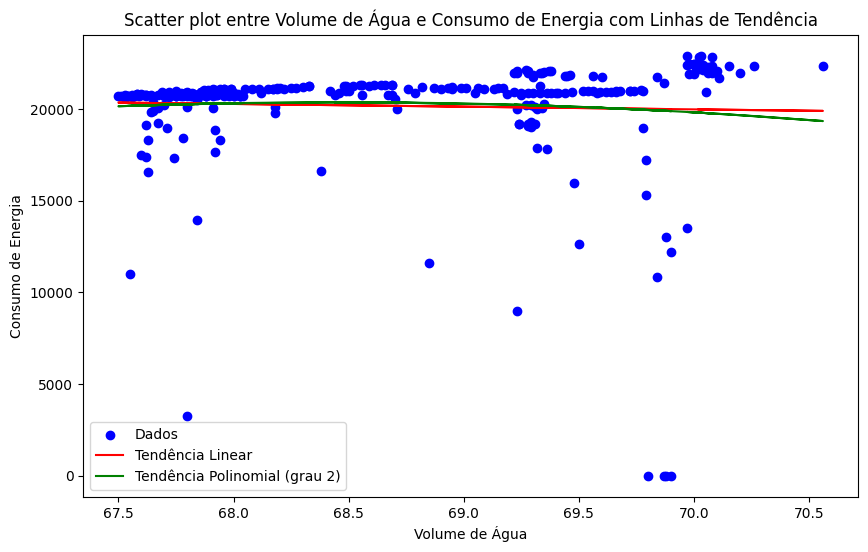

In [578]:
### GRÁFICO DE DISPERSÃO COM LINHA DE TENDÊNCIA LINEAR E POLINOMIAL
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from numpy.polynomial.polynomial import Polynomial

# Volume e Consumo de Energia
volume = final_du_df['cota'].values.reshape(-1, 1)
consumo = final_du_df['kwh'].values

# Gráfico de dispersão
plt.figure(figsize=(10, 6))
plt.scatter(volume, consumo, color='blue', label='Dados')

# Linha de tendência linear
linear_model = LinearRegression()
linear_model.fit(volume, consumo)
linear_trend = linear_model.predict(volume)
plt.plot(volume, linear_trend, color='red', label='Tendência Linear')

# Linha de tendência polinomial (grau 2 como exemplo)
polynomial_coeffs = Polynomial.fit(volume.flatten(), consumo, deg=2).convert().coef
polynomial_trend = polynomial_coeffs[0] + polynomial_coeffs[1] * volume + polynomial_coeffs[2] * volume**2
plt.plot(volume, polynomial_trend, color='green', label='Tendência Polinomial (grau 2)')

# Configurações do gráfico
plt.xlabel('Volume de Água')
plt.ylabel('Consumo de Energia')
plt.title('Scatter plot entre Volume de Água e Consumo de Energia com Linhas de Tendência')
plt.legend()
plt.show()


In [579]:
### TESTE DE CAUSALIDADE DE GRANGER ###
# Avalia se o volume de água ajuda a prever o consumo de energia (causalidade temporal), 
# o que é particularmente útil em séries temporais
from statsmodels.tsa.stattools import grangercausalitytests
data = final_du_df[['kwh', 'cota']]
grangercausalitytests(data, maxlag=7)
# Um p-valor pequeno sugere que o volume de água pode ser um bom preditor do consumo de energia



Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1769  , p=0.6744  , df_denom=279, df_num=1
ssr based chi2 test:   chi2=0.1788  , p=0.6724  , df=1
likelihood ratio test: chi2=0.1787  , p=0.6725  , df=1
parameter F test:         F=0.1769  , p=0.6744  , df_denom=279, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4372  , p=0.6463  , df_denom=276, df_num=2
ssr based chi2 test:   chi2=0.8901  , p=0.6408  , df=2
likelihood ratio test: chi2=0.8887  , p=0.6412  , df=2
parameter F test:         F=0.4372  , p=0.6463  , df_denom=276, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.9896  , p=0.3981  , df_denom=273, df_num=3
ssr based chi2 test:   chi2=3.0450  , p=0.3847  , df=3
likelihood ratio test: chi2=3.0286  , p=0.3872  , df=3
parameter F test:         F=0.9896  , p=0.3981  , df_denom=273, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.5474  , p=0.1888  

{1: ({'ssr_ftest': (0.17685862310670644, 0.6744106360976334, 279.0, 1),
   'ssr_chi2test': (0.17876032873150974, 0.6724407659422311, 1),
   'lrtest': (0.17870369441061484, 0.6724896398910607, 1),
   'params_ftest': (0.17685862310682882, 0.674410636097499, 279.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.4371515937273227, 0.6463199263917171, 276.0, 2),
   'ssr_chi2test': (0.8901420133143311, 0.6407787748581095, 2),
   'lrtest': (0.8887351032708466, 0.6412296924866496, 2),
   'params_ftest': (0.4371515937275283, 0.646319926391588, 276.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.9896336254817786, 0.398104204829241, 273.0, 3),
   'ssr_chi2test': (3.045026539943934, 0.3847349349881391, 3),
   'lrtest': (3.028588135903192, 0.3872384159135891, 3),
   'params_ftest': (0.9896336254826495, 0.3981042048288379, 273.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0

Testando Sazonalidade e Tendência do Volume de Água:
ADF Statistic: -0.7896785803334311
p-value: 0.8221351212912252
Critical Value (1%): -3.4537536300652
Critical Value (5%): -2.8718443180148836
Critical Value (10%): -2.572260641818822
------------------------------


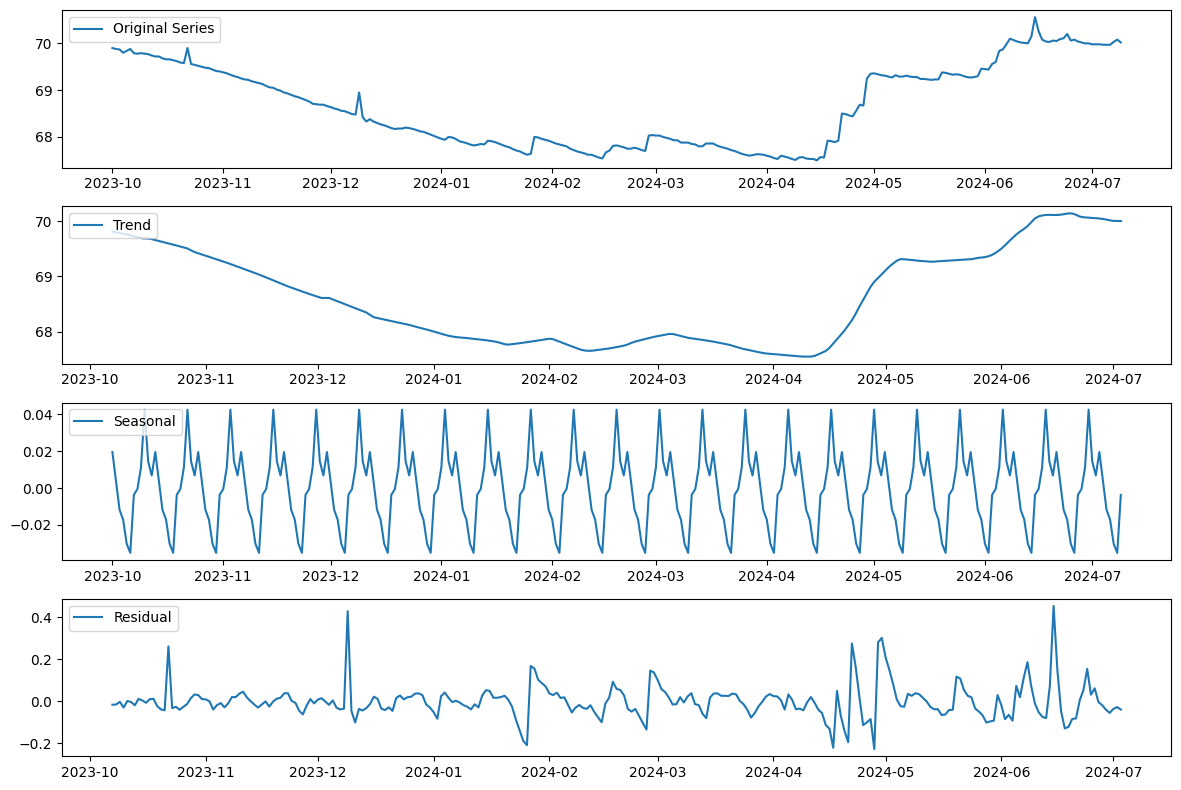

Testando Sazonalidade e Tendência do Consumo de Energia:
ADF Statistic: -10.733133680155305
p-value: 2.94480142171584e-19
Critical Value (1%): -3.4540076534999957
Critical Value (5%): -2.8719557347997178
Critical Value (10%): -2.5723200648758366
------------------------------


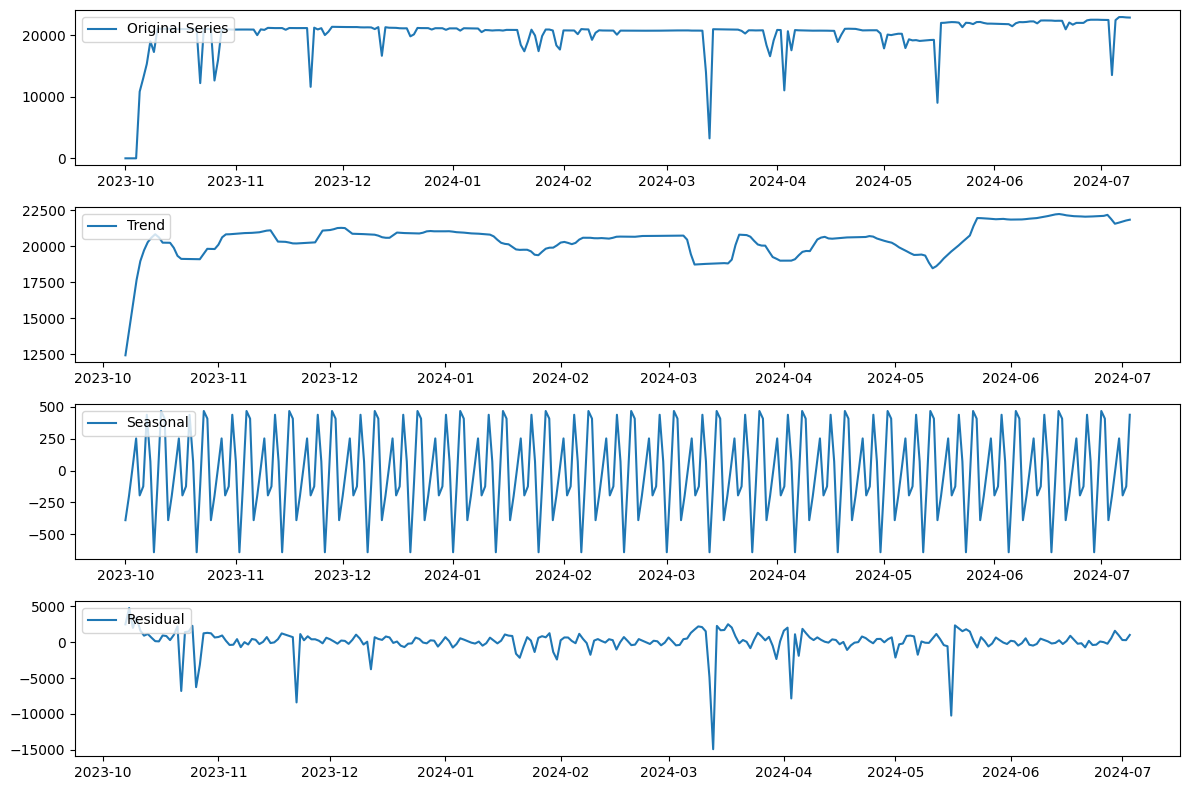

In [580]:
###
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# Supondo que você tenha um DataFrame df com as colunas 'data', 'volume_agua', e 'consumo_energia'
df = du_df_sazon_tend_test.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])  # Converter a coluna de data para o tipo datetime
df.set_index('timestamp', inplace=True)  # Definir a coluna de data como índice

# Função para testar a estacionaridade usando o teste ADF
def test_stationarity(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    # Um p-valor menor que 0.05 sugere que a série é estacionária
    for key, value in result[4].items():
        print(f'Critical Value ({key}):', value)
    print('---' * 10)

# Função para decompor a série temporal
def plot_decomposition(series):
    decomposition = seasonal_decompose(series, model='additive', period=12)  # Assumindo sazonalidade mensal
    trend = decomposition.trend
    seasonal = decomposition.seasonal
    residual = decomposition.resid

    plt.figure(figsize=(12, 8))

    plt.subplot(411)
    plt.plot(series, label='Original Series')
    plt.legend(loc='upper left')

    plt.subplot(412)
    plt.plot(trend, label='Trend')
    plt.legend(loc='upper left')

    plt.subplot(413)
    plt.plot(seasonal, label='Seasonal')
    plt.legend(loc='upper left')

    plt.subplot(414)
    plt.plot(residual, label='Residual')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Analisando o volume de água
print("Testando Sazonalidade e Tendência do Volume de Água:")
test_stationarity(df['cota'])
plot_decomposition(df['cota'])

# Analisando o consumo de energia
print("Testando Sazonalidade e Tendência do Consumo de Energia:")
test_stationarity(df['kwh'])
plot_decomposition(df['kwh'])


In [581]:
from sklearn.impute import SimpleImputer
print(X)
X['cota_diff'] = X['cota'].diff()
print(X)
X = X[['timestamp', 'cota_diff']].dropna().rename(columns={
    'cota_diff': 'cota'
})

# Verificar a presença de NaNs antes da imputação
print(X.isna().sum()) 
print(X)
print(y)
y = y[1:]
print(y)

     timestamp   cota
0     20231001  69.90
1     20231002  69.88
2     20231003  69.87
3     20231004  69.80
4     20231005  69.84
..         ...    ...
278   20240705  69.97
279   20240706  69.97
280   20240707  70.03
281   20240708  70.08
282   20240709  70.02

[283 rows x 2 columns]
     timestamp   cota  cota_diff
0     20231001  69.90        NaN
1     20231002  69.88      -0.02
2     20231003  69.87      -0.01
3     20231004  69.80      -0.07
4     20231005  69.84       0.04
..         ...    ...        ...
278   20240705  69.97       0.00
279   20240706  69.97       0.00
280   20240707  70.03       0.06
281   20240708  70.08       0.05
282   20240709  70.02      -0.06

[283 rows x 3 columns]
timestamp    0
cota         0
dtype: int64
     timestamp  cota
1     20231002 -0.02
2     20231003 -0.01
3     20231004 -0.07
4     20231005  0.04
5     20231006  0.04
..         ...   ...
278   20240705  0.00
279   20240706  0.00
280   20240707  0.06
281   20240708  0.05
282   20240709 -0.

In [582]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_train, y_train)



KNeighborsRegressor(n_neighbors=1)

In [583]:
y_pred = knn.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'rmse: {rmse:.2f}')

rmse: 1984.67


In [584]:
missing_volume_final = missing_volume_final[['timestamp', 'cota']].tail(180)
valid_df_missing = scaler.transform(missing_volume_final)
y_pred_validation = knn.predict(valid_df_missing)

In [585]:
# validation_df = scaler.transform(final_df_validation[['timestamp', 'cota']])
# y_pred_validation = knn.predict(validation_df)
# print(y_pred_validation)

      timestamp   cota         kwh
5030   20230404  68.06  21178.8198
5031   20230405  68.07  21178.8198
5032   20230406  68.07  21178.8198
5033   20230407  68.11  21178.8198
5034   20230408  68.11  21178.8198
...         ...    ...         ...
5205   20230926  69.98  21178.8198
5206   20230927  69.98  21178.8198
5207   20230928  69.95  21178.8198
5208   20230929  69.90  21178.8198
5209   20230930  69.90  21178.8198

[180 rows x 3 columns]


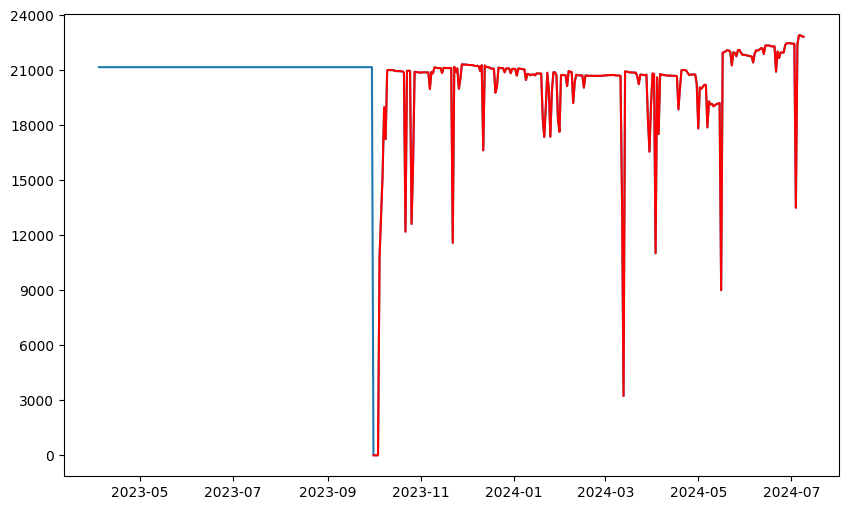

In [612]:
predict_validation_kwh = missing_volume_final.copy()
predict_validation_kwh['kwh'] = y_pred_validation
print(predict_validation_kwh)

predict_validation_kwh['timestamp'] = pd.to_datetime(predict_validation_kwh['timestamp'], format='%Y%m%d', errors='coerce')
final_du_df['timestamp'] = pd.to_datetime(final_du_df['timestamp'], format='%Y%m%d', errors='coerce')
# df_periodo = missing_volume_final[(missing_volume_final['timestamp'].dt.year >=2021)]
df_periodo = pd.concat([predict_validation_kwh, final_du_df])

plt.figure(figsize=(10,6))
plt.plot(df_periodo['timestamp'], df_periodo['kwh'])
plt.plot(final_du_df['timestamp'], final_du_df['kwh'], color= 'red')
plt.yticks(np.arange(0,25000,step=3000))
plt.show()


In [597]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Supondo que você já tenha o DataFrame X com as colunas de interesse
# Exemplo: X deve conter 'cota' (volume de água) e 'consumo' (consumo de energia)

# Simulação de dados (substitua isso pelo seu DataFrame real)
# X = pd.DataFrame({
#     'cota': [...],  # Dados de volume de água
#     'consumo': [...]  # Dados de consumo de energia
# })

# Exemplo de carga de dados
# X = pd.read_csv('seu_arquivo.csv')  # Carregue seu DataFrame

# Defina as variáveis independentes (X) e a dependente (y)


# Divida os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train)
# Escalonar os dados (opcional, mas pode melhorar a performance)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Inicialize o modelo Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Ajuste o modelo
rf_model.fit(X_train, y_train)

# Faça previsões
y_pred = rf_model.predict(X_test)

# Avalie o modelo
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')

# Exiba algumas previsões
predictions_df = pd.DataFrame({'Real': y_test, 'Previsto': y_pred})
print(predictions_df.head(50))

     cota
140  0.10
194 -0.03
20  -0.01
160  0.00
141  0.01
..    ...
189 -0.02
72   0.05
107 -0.02
271 -0.02
103  0.02

[225 rows x 1 columns]
Mean Squared Error: 5538866.809251697
Mean Absolute Error: 1469.7792390010663
         Real      Previsto
93   21080.52  20224.595012
94   20718.36  19638.811821
180  18343.44  20806.204584
125  20739.24  20224.595012
262  22320.00  19968.842442
234  22015.80  20224.595012
78   21089.88  20648.057742
10   21031.92  19968.842442
252  22087.44  20648.057742
265  22031.28  16559.055297
224  19101.24  19968.842442
269  21972.96  20806.204584
251  22104.00  21740.648400
214  20078.28  20224.595012
227  19220.40  20948.508482
46   21142.08  18706.962411
43   21130.56  18706.962411
147  20701.80  20224.595012
34   20897.64  20648.057742
245  21826.08  19968.842442
47   21133.44  20224.595012
248  21763.80  19539.871200
109  20834.28  20648.057742
221  19135.44  20948.508482
280  22919.40  19638.811821
217  20214.72  20224.595012
148  20704.32  20648.0

In [614]:
valid = valid_df_missing[:,1]
valid_reshaped = valid.reshape(-1, 1)
y_pred_validation_rf = rf_model.predict(valid_reshaped)
print(f"y_pred_validation_rf",y_pred_validation_rf)

y_pred_validation_rf [21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198 21178.8198
 21178.8198 21178.8198 21178.8198 21178.8

      timestamp   cota         kwh
5030   20230404  68.06  21178.8198
5031   20230405  68.07  21178.8198
5032   20230406  68.07  21178.8198
5033   20230407  68.11  21178.8198
5034   20230408  68.11  21178.8198
...         ...    ...         ...
5205   20230926  69.98  21178.8198
5206   20230927  69.98  21178.8198
5207   20230928  69.95  21178.8198
5208   20230929  69.90  21178.8198
5209   20230930  69.90  21178.8198

[180 rows x 3 columns]


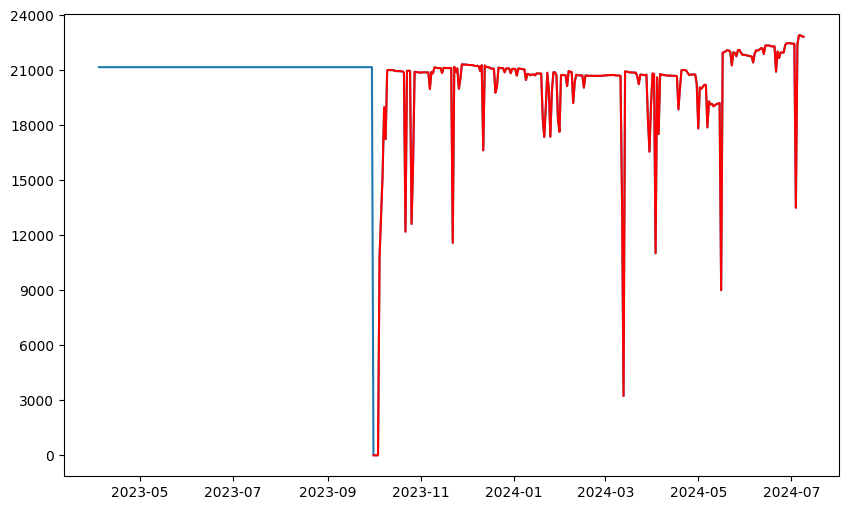

In [613]:
predict_validation_kwh = missing_volume_final.copy()
predict_validation_kwh['kwh'] = y_pred_validation_rf
print(predict_validation_kwh)

predict_validation_kwh['timestamp'] = pd.to_datetime(predict_validation_kwh['timestamp'], format='%Y%m%d', errors='coerce')
final_du_df['timestamp'] = pd.to_datetime(final_du_df['timestamp'], format='%Y%m%d', errors='coerce')
# df_periodo = missing_volume_final[(missing_volume_final['timestamp'].dt.year >=2021)]
df_periodo = pd.concat([predict_validation_kwh, final_du_df])

plt.figure(figsize=(10,6))
plt.plot(df_periodo['timestamp'], df_periodo['kwh'])
plt.plot(final_du_df['timestamp'], final_du_df['kwh'], color= 'red')
plt.yticks(np.arange(0,25000,step=3000))
plt.show()
